# Detecção de Fraude em Transações de Cartão de Crédito

**Disciplina:** Inteligência Artificial – 7ºJ SI - Noite
**Professor:** Prof. Dr. Leandro Zerbinatti

**Integrantes do grupo:**
- Anna Julia — [e-mail] — [RA]
- Eduarda — [e-mail] — [RA]
- Sara — [e-mail] — [RA]

**Síntese do conteúdo deste arquivo:** Preparação dos dados (parte da Anna Julia) — carregamento do dataset, separação de features/target, normalização de `Amount`/`Time`, split treino/teste estratificado e tratamento do desbalanceamento de classes (SMOTE).

**Histórico de alterações:**
| Data | Autor | Descrição |
|---|---|---|
| [13/09/2026] | Anna Julia | Criação do notebook — preparação dos dados |


## 1. Imports e carregamento do dataset

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Baixe o creditcard.csv em https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
df = pd.read_csv("../dataset/creditcard.csv")

print("Formato do dataset:", df.shape)
df.head()

Formato do dataset: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Checagem rápida (nulos, duplicatas, desbalanceamento)

> Obs.: a análise exploratória completa (gráficos de distribuição, histogramas, correlação) é a parte da Eduarda e da Sara — aqui só confirmamos que os dados estão prontos para a preparação.

In [6]:
print("Valores nulos por coluna:\n", df.isnull().sum().sum(), "nulos no total")
print("Linhas duplicadas:", df.duplicated().sum())

print("\nDistribuição da variável target (Class):")
print(df["Class"].value_counts())
print(df["Class"].value_counts(normalize=True) * 100)

Valores nulos por coluna:
 0 nulos no total
Linhas duplicadas: 1081

Distribuição da variável target (Class):
Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


## 3. Separar features (X) e target (y)

In [7]:
X = df.drop(columns=["Class"])
y = df["Class"]

print("X:", X.shape, " y:", y.shape)

X: (284807, 30)  y: (284807,)


## 4. Normalizar `Amount` e `Time`

As colunas `V1`–`V28` já vêm escaladas pelo PCA original do dataset. Só `Amount` e `Time` estão em escalas diferentes, então normalizamos só essas duas.

In [8]:
scaler = StandardScaler()
X[["Amount", "Time"]] = scaler.fit_transform(X[["Amount", "Time"]])

X[["Amount", "Time"]].describe()

,Amount,Time
count,2.848070e+05,2.848070e+05
mean,-3.672378e-17,-5.109395e-17
std,1.000002e+00,1.000002e+00
min,-3.532294e-01,-1.996583e+00
25%,-3.308401e-01,-8.552120e-01
50%,-2.652715e-01,-2.131453e-01
75%,-4.471707e-02,9.372174e-01
max,1.023622e+02,1.642058e+00


## 5. Separar treino e teste (estratificado)

Usamos `stratify=y` porque as classes são muito desbalanceadas (~0,17% de fraude): sem isso, o conjunto de teste poderia acabar com pouquíssimos exemplos de fraude, prejudicando a avaliação do modelo mais pra frente.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape, " Teste:", X_test.shape)
print("\nProporção de fraude no treino:", y_train.mean())
print("Proporção de fraude no teste:", y_test.mean())

Treino: (227845, 30)  Teste: (56962, 30)

Proporção de fraude no treino: 0.001729245759178389
Proporção de fraude no teste: 0.0017204452090867595


## 6. Tratar o desbalanceamento (SMOTE)

Aplicamos o SMOTE **só no treino** (nunca no teste, para não inflar os resultados). O SMOTE gera exemplos sintéticos da classe minoritária (fraude) com base nos vizinhos mais próximos, em vez de simplesmente duplicar registros.

> Alternativa que também pode ser citada no relatório: usar `class_weight='balanced'` direto no modelo (ex. `RandomForestClassifier(class_weight='balanced')`), sem alterar o dataset de treino. Optamos pelo SMOTE aqui, mas vale justificar a escolha no texto da Metodologia.

In [10]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Antes do SMOTE:")
print(y_train.value_counts())
print("\nDepois do SMOTE:")
print(y_train_res.value_counts())

Antes do SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

Depois do SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


## 7. Visualização do desbalanceamento antes/depois do SMOTE

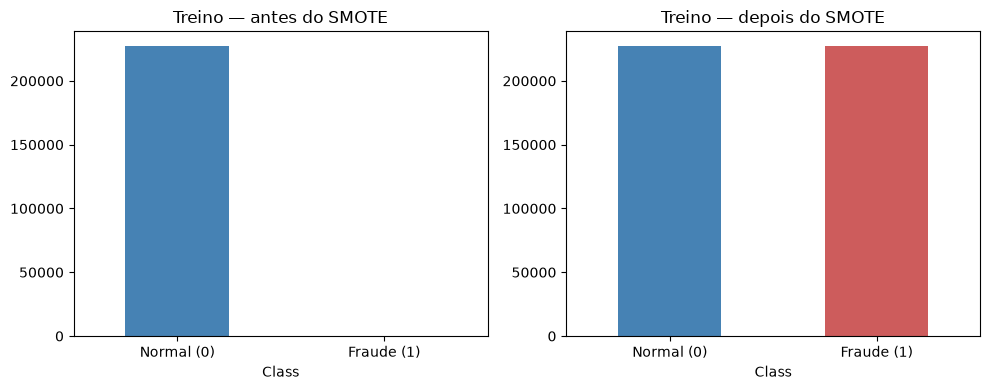

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

y_train.value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "indianred"])
axes[0].set_title("Treino — antes do SMOTE")
axes[0].set_xticklabels(["Normal (0)", "Fraude (1)"], rotation=0)

y_train_res.value_counts().plot(kind="bar", ax=axes[1], color=["steelblue", "indianred"])
axes[1].set_title("Treino — depois do SMOTE")
axes[1].set_xticklabels(["Normal (0)", "Fraude (1)"], rotation=0)

plt.tight_layout()
plt.show()

## 8. Salvar os dados preparados

Salvamos os conjuntos prontos para a N2, onde entram os modelos (Random Forest / XGBoost / Logistic Regression) e a avaliação com métricas adequadas a dados desbalanceados (AUPRC, recall, precision — não só acurácia).

In [12]:
X_train_res.to_csv("X_train_prepared.csv", index=False)
y_train_res.to_csv("y_train_prepared.csv", index=False)
X_test.to_csv("X_test_prepared.csv", index=False)
y_test.to_csv("y_test_prepared.csv", index=False)

print("Arquivos salvos com sucesso.")

Arquivos salvos com sucesso.
